# 1. Residual Load and Day-Ahead Prices

Explore how residual load (demand minus wind and solar) drives day-ahead prices on the Polish power market.


## Load data


In [ ]:
from clarwise import ClarwiseClient
import calendar

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots



In [18]:
# Constants

DATA_START_DATE = '2024-01-01'
DATA_END_DATE = '2025-12-31'
ROW_LIMIT = 300_000
LOCAL_TIMEZONE = 'Europe/Warsaw'
RANDOM_SEED = 0
MAX_SCATTER_POINTS_PER_YEAR = 8_000
MAX_SCATTER_POINTS_SEASONAL = 30_000
LOWESS_FRAC_YEARLY = 0.3
LOWESS_FRAC_OVERALL = 0.2
BALANCING_MARKET_REFORM_DATE = '2024-06-14'

## Download data

In [19]:
client = ClarwiseClient()

generation = client.get_dataset(
    'generation_by_fuel_15min',
    start_date=DATA_START_DATE,
    end_date=DATA_END_DATE,
    limit=ROW_LIMIT,
    columns=[
    'interval_start_utc',
    'biomass',
    'fossil_brown_coal_lignite',
    'fossil_coal_derived_gas',
    'fossil_gas',
    'fossil_hard_coal',
    'fossil_oil',
    'hydro_pumped_storage',
    'hydro_run_of_river_and_poundage',
    'hydro_water_reservoir',
    'other_renewable',
    'other',
],
)
print(f'Generation rows: {len(generation):,}; columns: {len(generation.columns)}')
generation.head()

Generation rows: 70,080; columns: 12


,interval_start_utc,biomass,fossil_brown_coal_lignite,fossil_coal_derived_gas,fossil_gas,fossil_hard_coal,fossil_oil,hydro_pumped_storage,hydro_run_of_river_and_poundage,hydro_water_reservoir,other_renewable,other
0,2024-01-01T19:45:00,275.0,2493.0,52.0,1953.0,6097.0,371.0,193.0,304.0,42.0,0.0,0.0
1,2024-01-01T02:45:00,273.0,1875.0,47.0,1532.0,5794.0,370.0,7.0,247.0,0.0,0.0,0.0
2,2024-01-01T19:15:00,275.0,2493.0,52.0,1953.0,6097.0,371.0,193.0,304.0,42.0,0.0,0.0
3,2024-01-01T11:45:00,275.0,2584.0,59.0,1914.0,6195.0,368.0,66.0,281.0,0.0,0.0,0.0
4,2024-01-01T07:00:00,276.0,1941.0,51.0,1812.0,5993.0,366.0,12.0,292.0,42.0,0.0,0.0


In [20]:
prices = client.get_dataset(
    'prices_15min',
    start_date=DATA_START_DATE,
    end_date=DATA_END_DATE,
    limit=ROW_LIMIT,
    columns=['interval_start_utc', 'rce'],
)

print(f'Prices rows: {len(prices):,}; columns: {len(prices.columns)}')
prices.head()

Prices rows: 70,172; columns: 2


,interval_start_utc,rce
0,2024-01-01T21:00:00,336.75
1,2024-01-01T10:15:00,346.93
2,2024-01-01T16:00:00,331.65
3,2024-01-01T01:30:00,240.02
4,2024-01-01T04:15:00,255.91


## Build hourly merged dataset

Aggregate the 15-minute generation and price series to hourly resolution. Residual load is
computed directly from `generation_by_fuel_15min` as the sum of all dispatchable fuel
categories (biomass, fossil, hydro, other) — i.e., total generation minus solar and wind —
and converted to GW. Hour-of-day and month are taken in Europe/Warsaw local time.


In [22]:
for dataset in (generation, prices):
    dataset['interval_start_utc'] = pd.to_datetime(dataset['interval_start_utc'], utc=True)

gen = generation.copy()
gen['residual_load_mw'] = gen[dispatchable_cols].fillna(0).sum(axis=1)

gen_h = (
    gen.set_index('interval_start_utc')[['residual_load_mw']]
    .sort_index()
    .resample('1h')
    .mean()
    .reset_index()
)
prices_h = (
    prices.set_index('interval_start_utc')[['rce']]
    .sort_index()
    .resample('1h')
    .mean()
    .reset_index()
)

df = (
    gen_h.merge(prices_h, on='interval_start_utc')
    .dropna(subset=['residual_load_mw', 'rce'])
    .sort_values('interval_start_utc')
    .reset_index(drop=True)
)
if df.empty:
    raise ValueError('Merged hourly dataset is empty after preprocessing.')

df['residual_load_gw'] = df['residual_load_mw'] / 1000.0

ts_local = df['interval_start_utc'].dt.tz_convert(LOCAL_TIMEZONE)
df['year'] = ts_local.dt.year
df['month'] = ts_local.dt.month
df['hour'] = ts_local.dt.hour
df['date_local'] = ts_local.dt.normalize().dt.tz_localize(None)

season_map = {
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn',
}
df['season'] = df['month'].map(season_map)

years_sorted = sorted(df['year'].unique())
print(f'Hourly observations: {len(df):,}')
print(f'Years available: {years_sorted}')
df.head()


Hourly observations: 17,519
Years available: [np.int32(2024), np.int32(2025)]


,interval_start_utc,residual_load_mw,rce,residual_load_gw,year,month,hour,date_local,season
0,2023-12-31 23:00:00+00:00,10685.0,258.17,10.685,2024,1,0,2024-01-01,Winter
1,2024-01-01 00:00:00+00:00,10377.0,258.90,10.377,2024,1,1,2024-01-01,Winter
2,2024-01-01 01:00:00+00:00,10296.0,240.02,10.296,2024,1,2,2024-01-01,Winter
3,2024-01-01 02:00:00+00:00,10145.0,239.38,10.145,2024,1,3,2024-01-01,Winter
4,2024-01-01 03:00:00+00:00,10189.0,239.09,10.189,2024,1,4,2024-01-01,Winter


## LOWESS smoother

Thin wrapper around `statsmodels.nonparametric.smoothers_lowess.lowess`. Returns the
smoothed curve on a sorted-x grid plus an R² evaluated at the original data points.


In [23]:
from statsmodels.nonparametric.smoothers_lowess import lowess

def lowess_smooth(x, y, frac=0.3):
    """LOWESS fit. Returns (grid_x, grid_y, r2_at_data_points)."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]
    if len(x) < 30:
        return None, None, np.nan
    sm = lowess(y, x, frac=frac, it=1, return_sorted=True)
    grid_x, grid_y = sm[:, 0], sm[:, 1]
    fit = np.interp(x, grid_x, grid_y)
    ss_res = float(((y - fit) ** 2).sum())
    ss_tot = float(((y - y.mean()) ** 2).sum())
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan
    return grid_x, grid_y, r2


## Figure 1 - Year-by-year scatter with LOWESS fit

Hourly market price (PLN/MWh) vs residual load (GW). The
black line is a LOWESS smoother.

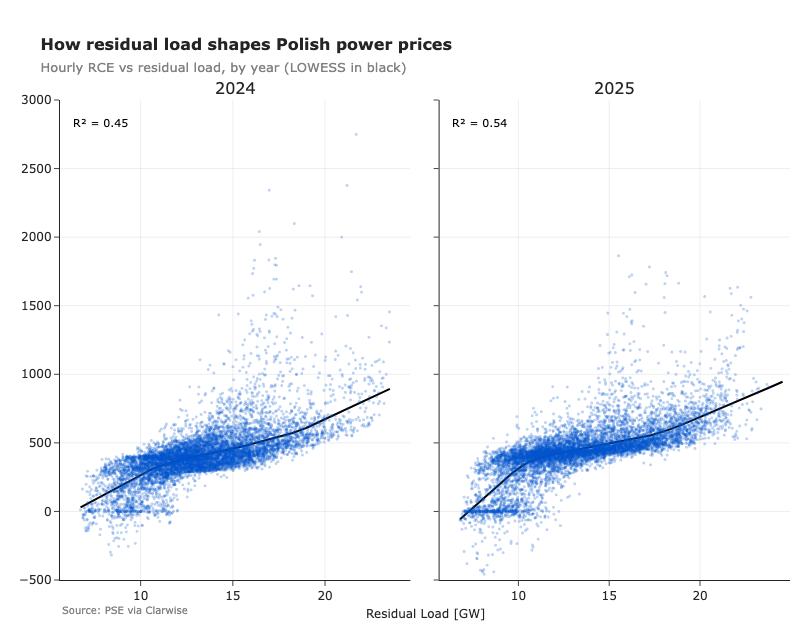

In [25]:
n_years = len(years_sorted)
cols = min(3, n_years) if n_years else 1
rows = max(1, (n_years + cols - 1) // cols)
fig1 = make_subplots(
    rows=rows,
    cols=cols,
    subplot_titles=[str(y) for y in years_sorted],
    shared_yaxes=True,
    shared_xaxes=False,
    horizontal_spacing=0.04,
    vertical_spacing=0.10,
)

year_stats = []
for i, year in enumerate(years_sorted):
    row, col = i // cols + 1, i % cols + 1
    sub = df[df['year'] == year]
    sample = sub.sample(min(len(sub), MAX_SCATTER_POINTS_PER_YEAR), random_state=RANDOM_SEED)

    fig1.add_trace(
        go.Scattergl(
            x=sample['residual_load_gw'],
            y=sample['rce'],
            mode='markers',
            marker=dict(size=3, opacity=0.25, color='#0052CC'),
            showlegend=False,
            name=str(year),
        ),
        row=row,
        col=col,
    )

    ex, ey, r2 = lowess_smooth(
        sub['residual_load_gw'].values,
        sub['rce'].values,
        frac=LOWESS_FRAC_YEARLY,
    )
    if ex is not None:
        fig1.add_trace(
            go.Scatter(
                x=ex,
                y=ey,
                mode='lines',
                line=dict(color='black', width=2),
                showlegend=False,
                name=f'{year} LOWESS',
            ),
            row=row,
            col=col,
        )
        fig1.add_annotation(
            text=f'R² = {r2:.2f}',
            xref=f'x{i+1} domain' if i else 'x domain',
            yref=f'y{i+1} domain' if i else 'y domain',
            x=0.03,
            y=0.97,
            xanchor='left',
            yanchor='top',
            showarrow=False,
            font=dict(size=11, color='black'),
        )

    year_stats.append(
        {
            'year': int(year),
            'r2_lowess': r2,
            'median_price_pln': float(sub['rce'].median()),
            'pct_hours_le_0': float((sub['rce'] <= 0).mean() * 100),
            'neg_price_hours': int((sub['rce'] <= 0).sum()),
            'n_hours': int(len(sub)),
        }
    )

fig1.update_yaxes(range=[-500, 3000])
fig1.update_xaxes(showgrid=True, gridcolor='rgba(200,200,200,0.3)', zeroline=False)
fig1.update_yaxes(showgrid=True, gridcolor='rgba(200,200,200,0.3)', zeroline=False)
fig1.update_layout(
    title=dict(
        text=(
            "<span style='font-size:16px;font-weight:bold'>How residual load shapes Polish power prices</span>"
            "<br><span style='font-size:13px;color:gray'>Hourly RCE vs residual load, by year (LOWESS in black)</span>"
        )
    ),
    template='simple_white',
    plot_bgcolor='#ffffff',
    paper_bgcolor='#ffffff',
    height=640 * rows,
    margin=dict(t=100, b=60, l=60, r=20),
)
fig1.add_annotation(
    text='Source: PSE via Clarwise',
    xref='paper',
    yref='paper',
    x=0.0,
    y=-0.08,
    xanchor='left',
    showarrow=False,
    font=dict(size=10, color='gray'),
)
fig1.add_annotation(
    text='Residual Load [GW]',
    x=0.5,
    y=-0.05,
    xref='paper',
    yref='paper',
    xanchor='center',
    yanchor='top',
    showarrow=False,
)
fig1.show()


## Per-year statistics

Compute LOWESS R², median price, % hours at price ≤ 0, and the absolute
count of negative-price hours. 


In [26]:
year_stats_df = pd.DataFrame(year_stats).sort_values('year').reset_index(drop=True)
year_stats_df['r2_lowess'] = year_stats_df['r2_lowess'].round(3)
year_stats_df['median_price_pln'] = year_stats_df['median_price_pln'].round(1)
year_stats_df['pct_hours_le_0'] = year_stats_df['pct_hours_le_0'].round(2)
year_stats_df


,year,r2_lowess,median_price_pln,pct_hours_le_0,neg_price_hours,n_hours
0,2024,0.451,396.6,2.33,204,8759
1,2025,0.540,442.6,4.06,356,8760


## Overall variance explained

Single-number R² for the residual-load → price relationship over the full sample, plus
the latest year and the worst year


In [27]:
_, _, overall_r2 = lowess_smooth(
    df['residual_load_gw'].values,
    df['rce'].values,
    frac=LOWESS_FRAC_OVERALL,
)
valid_r2 = year_stats_df.dropna(subset=['r2_lowess'])
if valid_r2.empty:
    raise ValueError('LOWESS R² could not be computed for any year.')
best_year_row = valid_r2.loc[valid_r2['r2_lowess'].idxmax()]
worst_year_row = valid_r2.loc[valid_r2['r2_lowess'].idxmin()]
latest_year_row = year_stats_df.iloc[-1]

print(
    f'Overall LOWESS R² (all years pooled): {overall_r2:.3f}'
    f'  → residual load alone explains ~{overall_r2*100:.0f}% of hourly price variance'
)
print(f'Worst year:   {int(worst_year_row["year"])}  R² = {worst_year_row["r2_lowess"]:.2f}')
print(f'Latest year:  {int(latest_year_row["year"])}  R² = {latest_year_row["r2_lowess"]:.2f}')
print(f'Best year:    {int(best_year_row["year"])}  R² = {best_year_row["r2_lowess"]:.2f}')


Overall LOWESS R² (all years pooled): 0.493  → residual load alone explains ~49% of hourly price variance
Worst year:   2024  R² = 0.45
Latest year:  2025  R² = 0.54
Best year:    2025  R² = 0.54


## Negative and zero prices

Hours clearing at zero or below — concentrated at the low-residual-load tail and growing
year-over-year as RES penetration rises.


In [28]:
neg = year_stats_df[['year', 'neg_price_hours', 'pct_hours_le_0']].copy()
neg.columns = ['year', 'hours_le_0', 'pct_hours_le_0']
print(neg.to_string(index=False))

low_resid_threshold = 10.0  # GW
low = df[df['residual_load_gw'] < low_resid_threshold]
if len(low):
    print(f'\nBelow {low_resid_threshold:.0f} GW residual load ({len(low):,} hours): '
          f'{(low["rce"] <= 0).mean()*100:.1f}% clear ≤ 0, '
          f'mean price {low["rce"].mean():.1f} PLN/MWh.')


 year  hours_le_0  pct_hours_le_0
 2024         204            2.33
 2025         356            4.06

Below 10 GW residual load (2,578 hours): 17.4% clear ≤ 0, mean price 182.1 PLN/MWh.


## Figure 2: Seasonal view (Winter vs Summer)

Same scatter restricted to Winter and Summer with per-season LOWESS curves overlaid. The
winter range extends further to the right (heating); the summer curve sits visibly above
winter at equivalent residual loads.


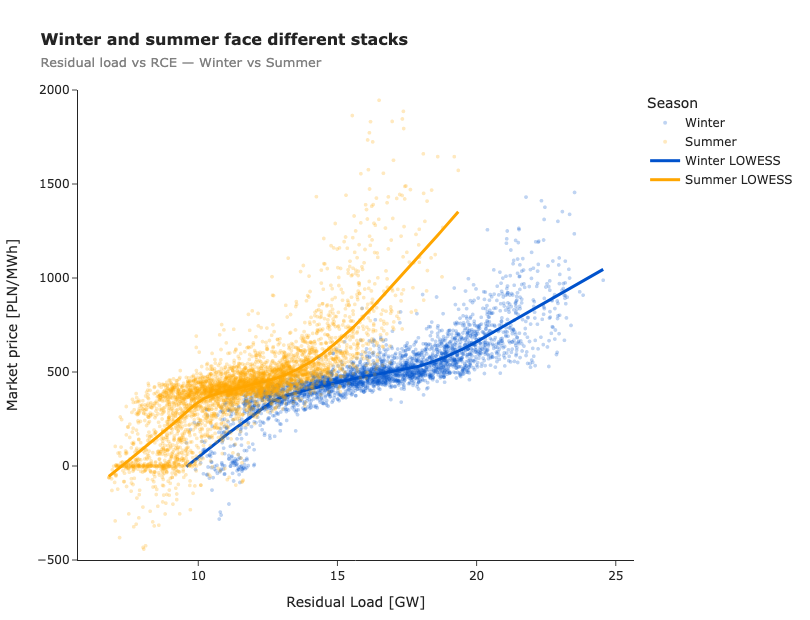

Winter: residual P01–P99 = [10.0, 22.7] GW, % hours ≤ 0: 0.97%, median price: 443.0
Summer: residual P01–P99 = [7.3, 17.3] GW, % hours ≤ 0: 5.08%, median price: 421.8


In [29]:
df_post_reform = df[df['interval_start_utc'] >= BALANCING_MARKET_REFORM_DATE].copy()
df_ws = df_post_reform[df_post_reform['season'].isin(['Winter', 'Summer'])].copy()

season_colors = {'Winter': '#0052CC', 'Summer': '#FFA600'}

sample = df_ws.sample(min(len(df_ws), MAX_SCATTER_POINTS_SEASONAL), random_state=RANDOM_SEED)
fig2 = px.scatter(
    sample,
    x='residual_load_gw',
    y='rce',
    color='season',
    color_discrete_map=season_colors,
    labels={
        'residual_load_gw': 'Residual Load [GW]',
        'rce': 'Market price [PLN/MWh]',
        'season': 'Season',
    },
)
fig2.update_traces(mode='markers', marker=dict(size=4, opacity=0.25))

for season in ['Winter', 'Summer']:
    sub = df_ws[df_ws['season'] == season]
    ex, ey, _ = lowess_smooth(sub['residual_load_gw'].values, sub['rce'].values, frac=LOWESS_FRAC_YEARLY)
    if ex is not None:
        fig2.add_trace(
            go.Scatter(
                x=ex,
                y=ey,
                mode='lines',
                line=dict(color=season_colors[season], width=3),
                name=f'{season} LOWESS',
                showlegend=True,
            )
        )

fig2.update_layout(
    title=dict(
        text=(
            "<span style='font-size:16px;font-weight:bold'>Winter and summer face different stacks</span>"
            "<br><span style='font-size:13px;color:gray'>Residual load vs RCE — Winter vs Summer</span>"
        )
    ),
    template='simple_white',
    plot_bgcolor='#ffffff',
    paper_bgcolor='#ffffff',
    height=620,
    margin=dict(t=90, b=60, l=60, r=20),
)
fig2.update_yaxes(range=[-500, 2000])
fig2.show()

for season in ['Winter', 'Summer']:
    sub = df[df['season'] == season]
    print(
        f'{season}: residual P01–P99 = '
        f'[{sub["residual_load_gw"].quantile(0.01):.1f}, '
        f'{sub["residual_load_gw"].quantile(0.99):.1f}] GW, '
        f'% hours ≤ 0: {(sub["rce"] <= 0).mean()*100:.2f}%, '
        f'median price: {sub["rce"].median():.1f}'
    )


## Figure 3: Sensitivity surface (∂Price / ∂ResidualLoad)

Local linear slope of price on residual load fitted *within each (month, hour) cell* across
all available years. Units: PLN/MWh per GW. Cells with fewer than 50 observations are
masked.


Sensitivity surface fitted on 13,583 hours from 2024-06-14 to 2025-12-31.


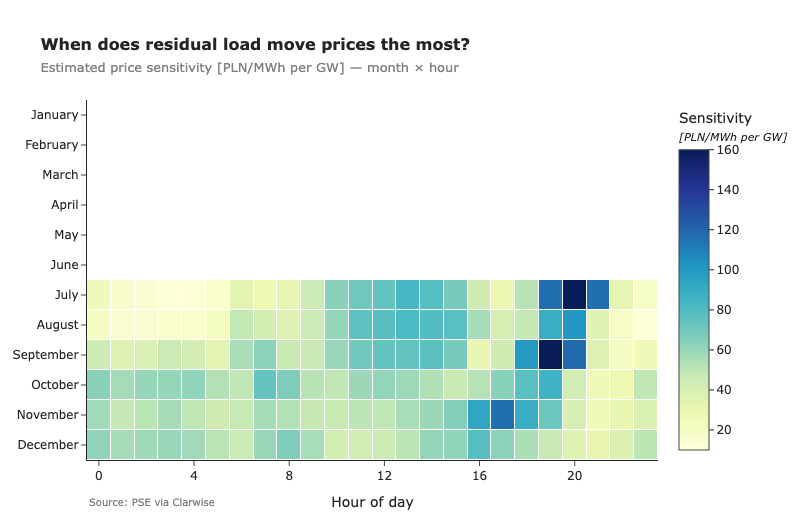

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
month,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,25.0,17.0,14.0,11.0,11.0,15.0,34.0,29.0,32.0,45.0,...,79.0,69.0,43.0,30.0,51.0,117.0,162.0,116.0,32.0,19.0
8,21.0,15.0,14.0,15.0,16.0,22.0,48.0,41.0,37.0,46.0,...,80.0,78.0,56.0,41.0,48.0,90.0,100.0,34.0,19.0,11.0
9,44.0,36.0,38.0,45.0,42.0,34.0,55.0,63.0,47.0,46.0,...,77.0,69.0,31.0,44.0,99.0,206.0,117.0,37.0,21.0,25.0


In [30]:
def cell_slope(group, xcol='residual_load_gw', ycol='rce', min_n=50):
    x = group[xcol].to_numpy(dtype=float)
    y = group[ycol].to_numpy(dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]
    if len(x) < min_n:
        return np.nan
    lo, hi = np.quantile(x, [0.005, 0.995])
    mid_mask = (x >= lo) & (x <= hi)
    x, y = x[mid_mask], y[mid_mask]
    if len(x) < min_n or x.std() == 0:
        return np.nan
    slope, _intercept = np.polyfit(x, y, 1)
    return float(slope)

def build_sensitivity_surface(data, min_n=50):
    rows = []
    for (month, hour), group in data.groupby(['month', 'hour']):
        rows.append(
            {
                'month': int(month),
                'hour': int(hour),
                'slope_pln_per_gw': cell_slope(group, min_n=min_n),
                'n': len(group),
                'mean_residual_gw': float(group['residual_load_gw'].mean()),
            }
        )
    return pd.DataFrame(rows).sort_values(['month', 'hour']).reset_index(drop=True)

# Restrict to the period where the system is structurally comparable to today


df_sens = df[df['interval_start_utc'] >= BALANCING_MARKET_REFORM_DATE]
print(
    f'Sensitivity surface fitted on {len(df_sens):,} hours '
    f'from {df_sens["interval_start_utc"].min().date()} '
    f'to {df_sens["interval_start_utc"].max().date()}.'
)

sens = build_sensitivity_surface(df_sens, min_n=50)
month_names = [calendar.month_name[m] for m in range(1, 13)]
heat = sens.pivot(index='month', columns='hour', values='slope_pln_per_gw').reindex(
    index=range(1, 13),
    columns=range(0, 24),
)

fig3 = go.Figure(
    data=go.Heatmap(
        z=heat.values,
        x=list(heat.columns),
        y=[month_names[m - 1] for m in heat.index],
        colorscale='YlGnBu',
        zmin=10,
        zmax=160,
        colorbar=dict(
            title=(
                'Sensitivity<br>'
                "<span style='font-size:11px;font-style:italic'>[PLN/MWh per GW]</span>"
            ),
            ticks='outside',
        ),
        xgap=1,
        ygap=1,
    )
)
fig3.update_layout(
    title=dict(
        text=(
            "<span style='font-size:16px;font-weight:bold'>When does residual load move prices the most?</span>"
            "<br><span style='font-size:13px;color:gray'>Estimated price sensitivity [PLN/MWh per GW] — month × hour</span>"
        )
    ),
    template='simple_white',
    plot_bgcolor='#ffffff',
    paper_bgcolor='#ffffff',
    height=520,
    margin=dict(t=100, b=60, l=80, r=40),
)
fig3.update_xaxes(
    title='Hour of day',
    tickmode='array',
    tickvals=[0, 4, 8, 12, 16, 20],
    showgrid=False,
)
fig3.update_yaxes(autorange='reversed', showgrid=False)
fig3.add_annotation(
    text='Source: PSE via Clarwise',
    xref='paper',
    yref='paper',
    x=0.0,
    y=-0.14,
    xanchor='left',
    showarrow=False,
    font=dict(size=10, color='gray'),
)
fig3.show()

heat.round(0)


## Sensitivity table: key regimes

Pulls out the specific (month, hour) cells the blog quotes.


In [31]:
def sens_at(month, hour):
    row = sens[(sens['month'] == month) & (sens['hour'] == hour)]
    if row.empty:
        return np.nan
    return float(row['slope_pln_per_gw'].iloc[0])

regimes = pd.DataFrame(
    [
        ('Summer midday trough', 7, 12),
        ('Summer evening peak', 7, 19),
        ('Winter morning ramp', 1, 7),
        ('Winter evening peak', 1, 18),
        ('Summer night trough', 7, 3),
        ('Shoulder afternoon', 4, 15),
    ],
    columns=['regime', 'month', 'hour'],
)
regimes['sensitivity_pln_mwh_per_gw'] = regimes.apply(
    lambda r: sens_at(int(r['month']), int(r['hour'])),
    axis=1,
).round(0)
regimes


,regime,month,hour,sensitivity_pln_mwh_per_gw
0,Summer midday trough,7,12,75.0
1,Summer evening peak,7,19,117.0
2,Winter morning ramp,1,7,NaN
3,Winter evening peak,1,18,NaN
4,Summer night trough,7,3,11.0
5,Shoulder afternoon,4,15,NaN


## Marginal sensitivity by time-of-day band

Average sensitivity in the midday solar window (10–15), evening peak (17–21), and night
trough (00–05).


In [33]:
def band_mean(months, hours):
    sel = sens[sens['month'].isin(months) & sens['hour'].isin(hours)]
    if sel.empty:
        return np.nan
    return float(sel['slope_pln_per_gw'].mean())

all_months = list(range(1, 13))
summer_months = [6, 7, 8]
winter_months = [12, 1, 2]

bands = pd.DataFrame(
    [
        ('All year', 'Midday (10–15)', band_mean(all_months, range(10, 16))),
        ('All year', 'Evening (17–21)', band_mean(all_months, range(17, 22))),
        ('All year', 'Night (00–05)', band_mean(all_months, range(0, 6))),
        ('Summer', 'Midday (10–15)', band_mean(summer_months, range(10, 16))),
        ('Summer', 'Evening (17–21)', band_mean(summer_months, range(17, 22))),
        ('Winter', 'Evening (17–21)', band_mean(winter_months, range(17, 22))),
    ],
    columns=['season', 'band', 'avg_sensitivity_pln_per_gw'],
)
bands['avg_sensitivity_pln_per_gw'] = bands['avg_sensitivity_pln_per_gw'].round(0)
bands


,season,band,avg_sensitivity_pln_per_gw
0,All year,Midday (10–15),63.0
1,All year,Evening (17–21),72.0
2,All year,Night (00–05),40.0
3,Summer,Midday (10–15),75.0
4,Summer,Evening (17–21),79.0
5,Winter,Evening (17–21),46.0


## Out-of-sample validation

Train the sensitivity surface on all-but-the-last available year, evaluate on the held-out
last year, and report the cell-wise correlation.


In [34]:
if len(years_sorted) >= 2:
    train_years = years_sorted[:-1]
    test_year = years_sorted[-1]

    train_surf = build_sensitivity_surface(
        df[df['year'].isin(train_years)],
        min_n=20,
    ).rename(columns={'slope_pln_per_gw': 'train'})
    test_surf = build_sensitivity_surface(
        df[df['year'] == test_year],
        min_n=20,
    ).rename(columns={'slope_pln_per_gw': 'test'})

    merged = train_surf[['month', 'hour', 'train']].merge(
        test_surf[['month', 'hour', 'test']],
        on=['month', 'hour'],
    ).dropna()
    corr = float(merged['train'].corr(merged['test']))

    print(f'Train years: {train_years}')
    print(f'Test year:   {test_year}')
    print(f'Cells compared: {len(merged)} / 288')
    print(f'Cell-wise correlation (train vs test slopes): {corr:.3f}')
    merged.head()
else:
    print('Need at least 2 years of data for out-of-sample validation.')


Train years: [np.int32(2024)]
Test year:   2025
Cells compared: 288 / 288
Cell-wise correlation (train vs test slopes): 0.590


## BESS value concentration

Approximation: hourly arbitrage value ≈ |price − daily mean|. Compute what share of total
annual arbitrage value is concentrated in the most extreme hours of the year.


In [35]:
df_arb = df.copy()
daily_mean = df_arb.groupby('date_local')['rce'].transform('mean')
df_arb['abs_spread'] = (df_arb['rce'] - daily_mean).abs()
total_value = float(df_arb['abs_spread'].sum())
if total_value <= 0:
    raise ValueError('Total arbitrage proxy value is zero; cannot compute concentration shares.')

rows__ = []
for top_pct in [1, 5, 10, 20, 50]:
    thr = df_arb['abs_spread'].quantile(1 - top_pct / 100.0)
    sub = df_arb[df_arb['abs_spread'] >= thr]
    rows__.append({
        'top_pct_hours': top_pct,
        'share_of_total_value_pct': round(sub['abs_spread'].sum() / total_value * 100, 1),
        'min_abs_spread_pln': round(float(thr), 1),
    })
concentration = pd.DataFrame(rows__)
concentration


,top_pct_hours,share_of_total_value_pct,min_abs_spread_pln
0,1,6.9,576.4
1,5,21.0,356.1
2,10,34.0,275.9
3,20,52.7,186.5
4,50,83.9,81.6


## Template values


In [36]:
print('=== TL;DR figures ===')
print(f'Overall R² (all years pooled):        {overall_r2*100:.0f}%')
print(f'Worst year R² ({int(worst_year_row["year"])}):                {worst_year_row["r2_lowess"]:.2f}')
print(f'Latest year R² ({int(latest_year_row["year"])}):               {latest_year_row["r2_lowess"]:.2f}')
print()
print('Sensitivity range (PLN/MWh per GW):')
print(f'  min cell: {sens["slope_pln_per_gw"].min():.0f}'
      f'  median: {sens["slope_pln_per_gw"].median():.0f}'
      f'  max cell: {sens["slope_pln_per_gw"].max():.0f}')
print()
print('Negative-price hours by year:')
for _, row in year_stats_df.iterrows():
    print(f'  {int(row["year"])}: {int(row["neg_price_hours"]):>4d} hours '
          f'({row["pct_hours_le_0"]:.2f}%)  median price {row["median_price_pln"]:.1f} PLN/MWh')
print()
print('Seasonal residual-load range (P01–P99, GW):')
for s in ['Winter', 'Summer']:
    sub = df[df['season'] == s]
    print(f'  {s}: [{sub["residual_load_gw"].quantile(0.01):.1f}, '
          f'{sub["residual_load_gw"].quantile(0.99):.1f}]')


=== TL;DR figures ===
Overall R² (all years pooled):        49%
Worst year R² (2024):                0.45
Latest year R² (2025):               0.54

Sensitivity range (PLN/MWh per GW):
  min cell: 11  median: 51  max cell: 206

Negative-price hours by year:
  2024:  204 hours (2.33%)  median price 396.6 PLN/MWh
  2025:  356 hours (4.06%)  median price 442.6 PLN/MWh

Seasonal residual-load range (P01–P99, GW):
  Winter: [10.0, 22.7]
  Summer: [7.3, 17.3]
